<h1 style="color:#1f77b4; font-family:'Times New Roman';">
<b>DBSCAN Intuition</b>
</h1>
<div style="font-family:'Times New Roman';">
<b>Goal:</b>
<ol>
<li>Understand what density based clustering means</li>
<li>See why DBSCAN is different from K-Means</li>
<li>Understand core points, border points and noise</li>
<li>Understand eps and min_pts and how clusters grow</li>
</ol>
K-Means was nice but it has some problems. We have to tell it how many clusters k beforehand, it assumes the clusters are round blobs, and it forces every single point into some cluster even if the point is clearly an outlier. DBSCAN takes a totally different route. It looks at how dense the points are. It can find clusters of any shape, it figures out the number of clusters on its own, and it can mark weird points as noise.
</div>

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>K-Means way vs the density way</b>
</h2>
<div style="font-family:'Times New Roman';">
The way K-Means thinks is, pick some centers and put each point with its nearest center. DBSCAN instead thinks, a cluster is just a bunch of points packed close together, and the empty low density areas are the gaps between clusters. So clusters are dense regions separated by sparse regions.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Lets look at some data that is not round</b>
</h2>
<div style="font-family:'Times New Roman';">
K-Means likes round blobs. But real data is not always like that. Let me make the two moons dataset which has two clusters shaped like crescents.
</div>

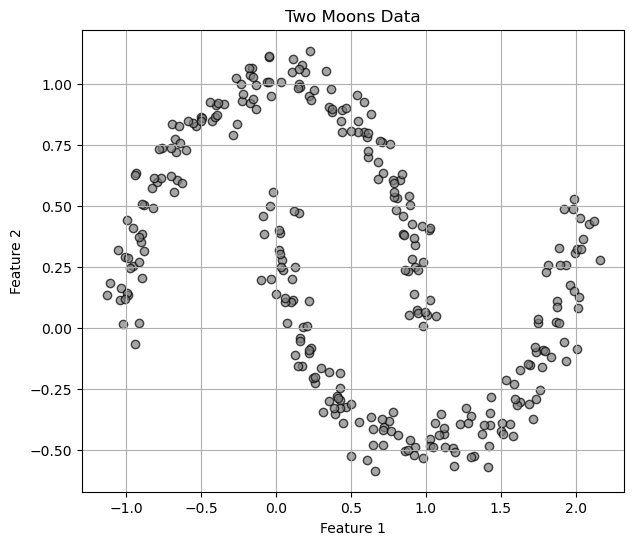

In [2]:
np.random.seed(42)
X, _ = make_moons(n_samples=300, noise=0.06, random_state=42)

plt.figure(figsize=(7, 6))
plt.scatter(X[:, 0], X[:, 1], color='gray', edgecolors='k', alpha=0.7)
plt.title("Two Moons Data")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>The two main settings, eps and min_pts</b>
</h2>
<div style="font-family:'Times New Roman';">
DBSCAN has just two main things to set.
<ul>
<li>eps is the radius of the neighborhood around a point. Basically how close is close.</li>
<li>min_pts is the minimum number of points that must be inside that eps radius for the area to count as dense.</li>
</ul>
Everything in DBSCAN is built on top of these two numbers.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Core points, border points and noise</b>
</h2>
<div style="font-family:'Times New Roman';">
Using eps and min_pts every point falls into one of three types.
<ul>
<li>Core point, it has at least min_pts points (including itself) inside its eps radius. These sit in the dense middle of a cluster.</li>
<li>Border point, it does not have enough neighbors to be core, but it is inside the eps radius of some core point. These sit on the edge of a cluster.</li>
<li>Noise point, it is neither core nor border. It is sitting alone in a low density area, so DBSCAN calls it noise.</li>
</ul>
</div>

Point 0 has 16 points inside eps=0.2 (including itself)
Is it a core point? True


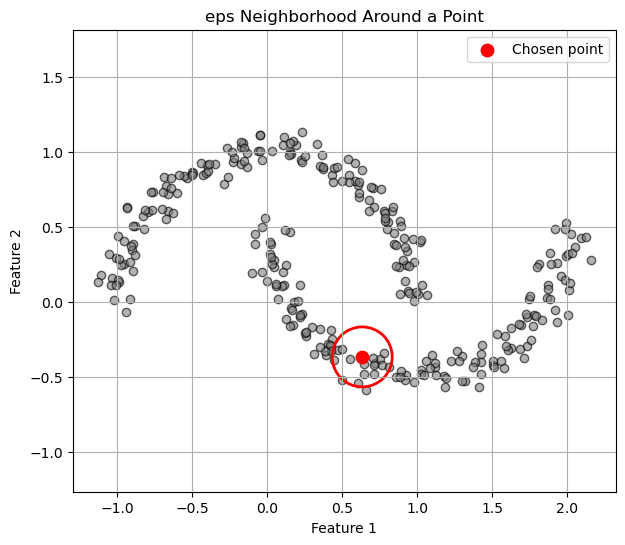

In [3]:
# pick one point and draw its eps neighborhood
eps = 0.2
min_pts = 5

idx = 0
point = X[idx]

# count how many points fall inside the eps circle
dists = np.sqrt(((X - point) ** 2).sum(axis=1))
neighbors = np.sum(dists <= eps)

print(f"Point {idx} has {neighbors} points inside eps={eps} (including itself)")
print("Is it a core point?", neighbors >= min_pts)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(X[:, 0], X[:, 1], color='gray', edgecolors='k', alpha=0.6)
ax.scatter(point[0], point[1], color='red', s=80, label='Chosen point')

# draw the eps circle
circle = plt.Circle((point[0], point[1]), eps, color='red', fill=False, lw=2)
ax.add_patch(circle)

ax.set_title("eps Neighborhood Around a Point")
ax.set_xlabel("Feature 1")
ax.set_ylabel("Feature 2")
ax.legend()
ax.axis('equal')
ax.grid(True)
plt.show()

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>How a cluster grows</b>
</h2>
<div style="font-family:'Times New Roman';">
DBSCAN starts at some core point and forms a cluster. Then it looks at all the neighbors of that core point. If a neighbor is also a core point, its neighbors get pulled into the same cluster too, and this keeps spreading. This chain reaction is how DBSCAN can follow a long curvy shape like a moon. The spreading stops when it reaches border points (no more dense neighbors) or runs into low density empty space.
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Where DBSCAN is good and where it is not</b>
</h2>
<div style="font-family:'Times New Roman';">
DBSCAN is great when:
<ul>
<li>the clusters have weird non convex shapes</li>
<li>there are outliers you actually want to detect instead of forcing them into a cluster</li>
<li>you do not know the number of clusters beforehand</li>
</ul>
But it has weak spots too:
<ul>
<li>if different clusters have very different densities one single eps does not fit all of them</li>
<li>choosing a good eps is a bit tricky</li>
<li>it struggles in very high dimensions because distances start to look the same everywhere</li>
</ul>
</div>

<h2 style="color:#1f77b4; font-family:'Times New Roman';">
<b>Summary</b>
</h2>
<div style="font-family:'Times New Roman';">
<ul>
<li>DBSCAN is a density based clustering method, clusters are dense regions separated by sparse ones</li>
<li>It does not need the number of clusters in advance</li>
<li>It uses two settings, eps (the radius) and min_pts (how many neighbors make an area dense)</li>
<li>Every point is either a core point, a border point or noise</li>
<li>Clusters grow by connecting core points to their neighbors, so any shape can be found</li>
<li>Unlike K-Means it can label outliers as noise instead of forcing them into a cluster</li>
</ul>
Next i will code DBSCAN from scratch with plain functions and run it on the moons data.
</div>